In [ ]:
import pandas as pd

# Load the features we built in Step 3
df = pd.read_csv('../data/processed/ml_features.csv', index_col=0, parse_dates=True)

feature_columns = [
    'copper_Close', 'zinc_proxy_Close', 'usdinr_Close', 'crude_Close', 'copx_Close',
    'Brass_Cost', 'Daily_Return', 'SMA_10', 'SMA_30', 'Volatility_14d'
]

X = df[feature_columns]          # The inputs
y = df['Target_Direction']       # The answer (1 = UP, 0 = DOWN)

print("Data ready for training.")

Data ready for training.


In [4]:
from sklearn.model_selection import train_test_split

# shuffle=False is MANDATORY for stock market data!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training on {len(X_train)} historical days...")
print(f"Testing on {len(X_test)} future days...")

Training on 3272 historical days...
Testing on 819 future days...


In [5]:
from sklearn.ensemble import RandomForestClassifier

# Create the model (with 100 trees)
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Train the model! (This is where the math happens)
model.fit(X_train, y_train)

print("Model successfully trained! 🧠")

Model successfully trained! 🧠


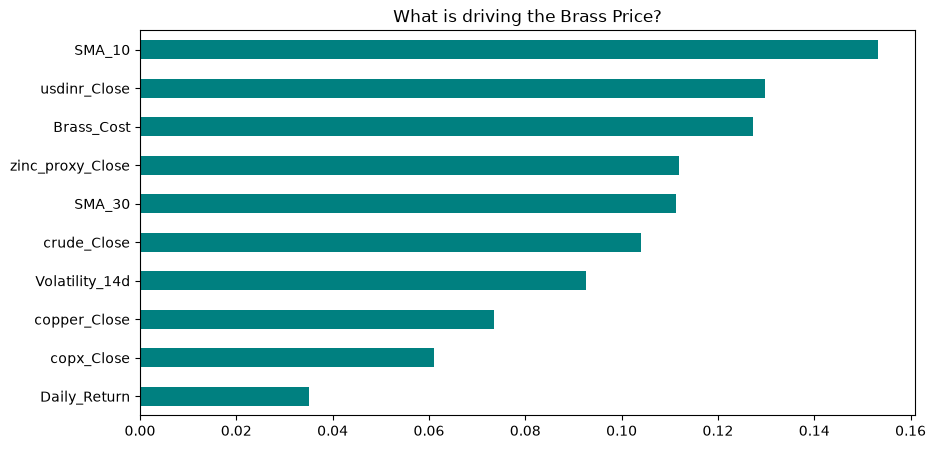

In [6]:
import matplotlib.pyplot as plt

# Get the importance scores
importances = model.feature_importances_

# Plot them
pd.Series(importances, index=feature_columns).sort_values().plot(
    kind='barh', 
    title='What is driving the Brass Price?', 
    figsize=(10,5),
    color='teal'
)
plt.show()

In [7]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save the model to a file
joblib.dump(model, '../models/brass_rf_model.joblib')
print("Model saved successfully to /models/brass_rf_model.joblib!")

Model saved successfully to /models/brass_rf_model.joblib!
